# Optimal Transport in linear Independent Component Analysis
### Simulated Experiment: Singe IC extraction with squared Wasserstein Distance - Discrete

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.stats

from wasserstein_ica import WassersteinICA

In [2]:
# Simulating Bernouli sources (s1 and s2) of size n=1000
n = 2000
np.random.seed(42)

# Bernoulli symmetric {-1,1}
S1 = np.where(np.random.rand(n) < 0.5, -1.0, 1.0)
S2 = np.where(np.random.rand(n) < 0.5, -1.0, 1.0)

# Stack sources
S = np.vstack([S1, S2])

In [3]:
# generating invertible mixing matrix A
#A = np.array([[1, 0.5], [0.4, 1]])
"""
A = np.array([
    [2.0,  1.0],  # Dominant axis (Mixes S1 and S2)
    [0.2, -0.4]   # Minor axis (Mixes S1 and S2 differently)
])
"""

A = np.array([
    [2.0,  0.0],  # Dominant axis (Mixes S1 and S2)
    [0.0, 0.5]   # Minor axis (Mixes S1 and S2 differently)
])

# Mixed signals X
X = A @ S

# Converting to pytorch tensors
S_torch = torch.tensor(S, dtype=torch.float32)
X_torch = torch.tensor(X, dtype=torch.float32)

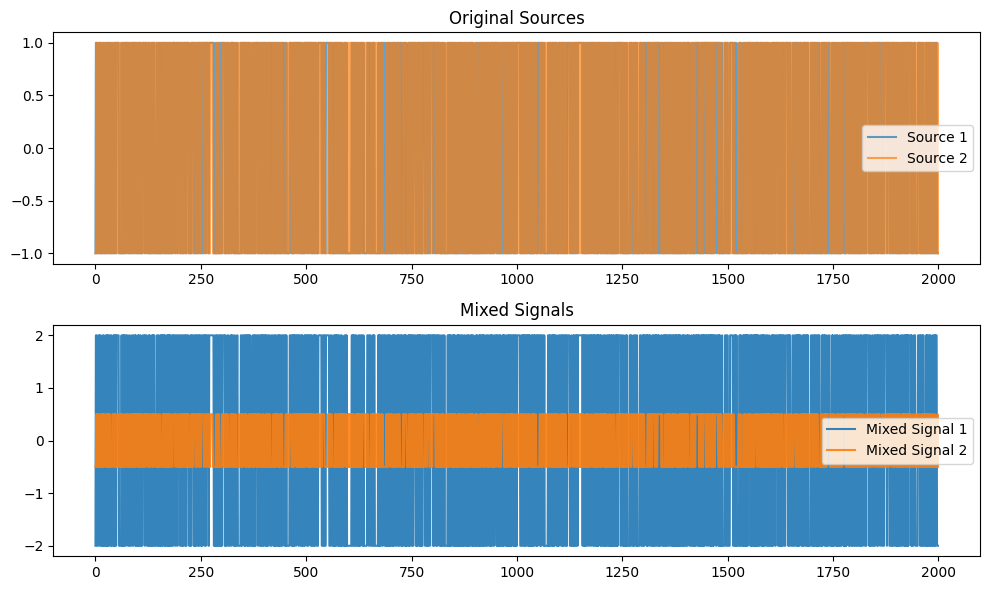

In [4]:
# Plotting sources and mixed signals
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.title("Original Sources")
plt.plot(S1, label='Source 1', alpha=0.7)
plt.plot(S2, label='Source 2', alpha=0.7)
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Mixed Signals")
plt.plot(X[0, :], label='Mixed Signal 1', alpha=0.9)
plt.plot(X[1, :], label='Mixed Signal 2', alpha=0.9)
plt.legend()

plt.tight_layout()
plt.show()

### Validating W1 and W2 from class above versus from `scipy.stats.wasserstin_distance` and `ot.emd2`

In [5]:
from scipy.stats import wasserstein_distance
import ot

# Compute distances using your class
ica = WassersteinICA(X_torch)
ica.whiten()
w1, dist1 = ica.optimize_wasserstein2(grid_points=100000, continuous=False)

proj_w1 = torch.mv(ica.X_white.t(), w1)
proj_np = proj_w1.detach().numpy()

# For fair comparison, generate theoretical normal quantiles at same positions
n = len(proj_np)
q_levels = np.linspace(0.5/n, 1 - 0.5/n, n)
theoretical_normal = scipy.stats.norm.ppf(q_levels)

# Direct comparison with sorted samples
sorted_proj = np.sort(proj_np)
W2_direct_squared = np.mean((sorted_proj - theoretical_normal) ** 2)
W2_direct = np.sqrt(W2_direct_squared)
W1_direct = np.mean(np.abs(sorted_proj - theoretical_normal))

print(f"Direct computation W1: {W1_direct:.6f}")
print(f"Direct computation W2: {W2_direct:.6f}")
print(f"Your class W1: {ica.wasserstein1_distance(w1):.6f}")
print(f"Your class W2: {dist1:.6f}")
print(f"Your class W2 (Root):  {np.sqrt(dist1):.6f}")
print(f"Match: {np.isclose(W2_direct_squared, dist1, rtol=1e-4)}")

# SciPy with theoretical samples
w1_scipy_theoretical = wasserstein_distance(proj_np, theoretical_normal)
print(f"\nSciPy W1 (vs theoretical normal): {w1_scipy_theoretical:.6f}")

# POT with theoretical samples
x = proj_np.reshape(-1, 1)
y = theoretical_normal.reshape(-1, 1)
a = np.ones(len(x)) / len(x)
b = np.ones(len(y)) / len(y)
M = ot.dist(x, y, metric='euclidean') ** 2
W2_squared_pot = ot.emd2(a, b, M)
W2_pot = np.sqrt(W2_squared_pot)
print(f"POT W2 (vs theoretical normal): {W2_pot:.6f}")

Direct computation W1: 0.535243
Direct computation W2: 0.635383
Your class W1: 0.535243
Your class W2: 0.403712
Your class W2 (Root):  0.635383
Match: True

SciPy W1 (vs theoretical normal): 0.535243
POT W2 (vs theoretical normal): 0.635383


In [6]:
# whitening and validation

ica = WassersteinICA(X_torch)
ica.whiten()

# Verify whitening
cov_white = torch.matmul(ica.X_white, ica.X_white.t()) / (ica.n - 1)
print("Whitened covariance (should be identity):")
print(cov_white.numpy())
print()

Whitened covariance (should be identity):
[[9.9995935e-01 4.0551434e-08]
 [4.0551434e-08 9.9999827e-01]]



In [7]:
# W1 vs W2 across all angles

n_grid = 1000
thetas = torch.linspace(0, 2*np.pi, steps=n_grid)
ws = torch.stack([torch.cos(thetas), torch.sin(thetas)], dim=1)

w1_distances = []
w2_distances = []

print("Computing Wasserstein distances across all angles...")
for w in ws:
    w_norm = w / torch.norm(w)
    w1_distances.append(ica.wasserstein1_distance(w_norm).item())
    w2_distances.append(ica.wasserstein2_distance(w_norm).item())

w1_distances = np.array(w1_distances)
w2_distances = np.array(w2_distances)

Computing Wasserstein distances across all angles...


In [8]:
# Find indices for key angles
theta_0_idx = 0
theta_pi2_idx = (np.abs(thetas.numpy() - np.pi/2)).argmin()
theta_pi_idx = (np.abs(thetas.numpy() - np.pi)).argmin()
theta_3pi2_idx = (np.abs(thetas.numpy() - 3*np.pi/2)).argmin()

print("\n" + "="*60)
print("WASSERSTEIN-1 DISTANCE ANALYSIS")
print("="*60)
print(f"θ = 0°   (0 rad):      W1 = {w1_distances[theta_0_idx]:.4f}")
print(f"θ = 90°  (π/2 rad):    W1 = {w1_distances[theta_pi2_idx]:.4f}")
print(f"θ = 180° (π rad):      W1 = {w1_distances[theta_pi_idx]:.4f}")
print(f"θ = 270° (3π/2 rad):   W1 = {w1_distances[theta_3pi2_idx]:.4f}")
print(f"Maximum W1:            W1 = {w1_distances.max():.4f} at θ = {thetas[w1_distances.argmax()].item():.3f} rad ({np.degrees(thetas[w1_distances.argmax()].item()):.1f}°)")
print(f"Minimum W1:            W1 = {w1_distances.min():.4f} at θ = {thetas[w1_distances.argmin()].item():.3f} rad ({np.degrees(thetas[w1_distances.argmin()].item()):.1f}°)")

print("\n" + "="*60)
print("WASSERSTEIN-2 DISTANCE ANALYSIS")
print("="*60)
print(f"θ = 0°   (0 rad):      W2² = {w2_distances[theta_0_idx]:.4f}")
print(f"θ = 90°  (π/2 rad):    W2² = {w2_distances[theta_pi2_idx]:.4f}")
print(f"θ = 180° (π rad):      W2² = {w2_distances[theta_pi_idx]:.4f}")
print(f"θ = 270° (3π/2 rad):   W2² = {w2_distances[theta_3pi2_idx]:.4f}")
print(f"Maximum W2:           W2² = {w2_distances.max():.4f} at θ = {thetas[w2_distances.argmax()].item():.3f} rad ({np.degrees(thetas[w2_distances.argmax()].item()):.1f}°)")
print(f"Minimum W2:           W2² = {w2_distances.min():.4f} at θ = {thetas[w2_distances.argmin()].item():.3f} rad ({np.degrees(thetas[w2_distances.argmin()].item()):.1f}°)")

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
print("Expected: Independent components recovered at θ = 0° and θ = 90°")
print(f"W2 is maximized near these angles: {w2_distances[theta_0_idx] > w2_distances.mean() or w2_distances[theta_pi2_idx] > w2_distances.mean()}")
print(f"W1 is inconsistent (not maximized at 0° or 90°): {w1_distances[theta_0_idx] < w1_distances.max() * 0.95 and w1_distances[theta_pi2_idx] < w1_distances.max() * 0.95}")



WASSERSTEIN-1 DISTANCE ANALYSIS
θ = 0°   (0 rad):      W1 = 0.5263
θ = 90°  (π/2 rad):    W1 = 0.5348
θ = 180° (π rad):      W1 = 0.5243
θ = 270° (3π/2 rad):   W1 = 0.5337
Maximum W1:            W1 = 0.5348 at θ = 1.572 rad (90.1°)
Minimum W1:            W1 = 0.2891 at θ = 2.616 rad (149.9°)

WASSERSTEIN-2 DISTANCE ANALYSIS
θ = 0°   (0 rad):      W2² = 0.3905
θ = 90°  (π/2 rad):    W2² = 0.4031
θ = 180° (π rad):      W2² = 0.3876
θ = 270° (3π/2 rad):   W2² = 0.4014
Maximum W2:           W2² = 0.4031 at θ = 1.572 rad (90.1°)
Minimum W2:           W2² = 0.1426 at θ = 5.761 rad (330.1°)

CONCLUSION
Expected: Independent components recovered at θ = 0° and θ = 90°
W2 is maximized near these angles: True
W1 is inconsistent (not maximized at 0° or 90°): False


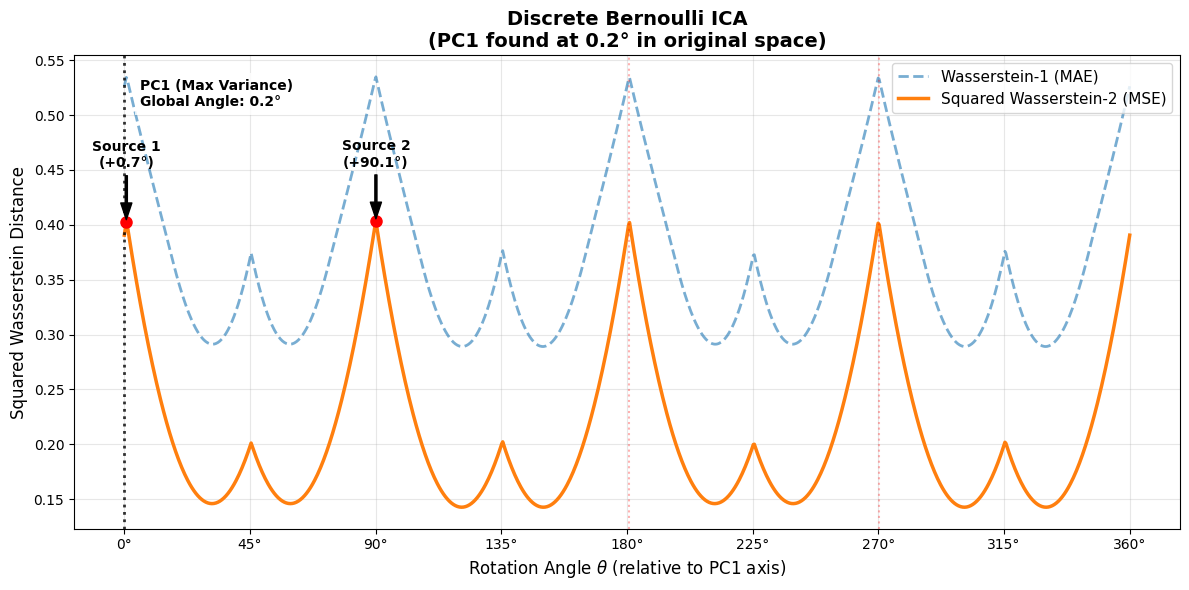

In [9]:
import matplotlib.pyplot as plt

# PC1 Angle Calculation
# We recalculate the angle of the First Principal Component in the original space
# to understand how much the data was rotated during whitening.

# Center data
X_centered = X_torch - torch.mean(X_torch, dim=1, keepdim=True)
cov_X = torch.matmul(X_centered, X_centered.t()) / (X_torch.shape[1] - 1)

# Eigendecomposition
D, E = torch.linalg.eigh(cov_X)

# Last column is PC1 (Max Variance)
pc1_vector = E[:, -1] 
pc1_angle_rad = torch.atan2(pc1_vector[1], pc1_vector[0]).item()
pc1_angle_deg = np.degrees(pc1_angle_rad)

# Normalize angle to -90 to 90 range for readability
if pc1_angle_deg > 90: pc1_angle_deg -= 180
if pc1_angle_deg < -90: pc1_angle_deg += 180

# Dynamic Peak Detection
# Instead of hardcoding lines, we find the actual peaks in W2 distance
# We assume thetas covers 0 to 2*pi. We look for peaks in the first half (0 to pi).

# Convert to numpy for easier handling
w2_np = np.array(w2_distances)
thetas_np = thetas.cpu().numpy()

# Split search into quadrants to find the two distinct orthogonal sources
# Assuming sources are roughly 90 degrees apart)
n_points = len(w2_np)
quarter_idx = n_points // 4
half_idx = n_points // 2

# Find Peak 1 (roughly in 0-90 range)
peak1_idx = np.argmax(w2_np[:quarter_idx])
theta_peak1 = thetas_np[peak1_idx]
val_peak1 = w2_np[peak1_idx]

# Find Peak 2 (roughly in 90-180 range)
# We search the second quarter
peak2_idx = np.argmax(w2_np[quarter_idx:half_idx]) + quarter_idx
theta_peak2 = thetas_np[peak2_idx]
val_peak2 = w2_np[peak2_idx]

# Plotting
plt.figure(figsize=(12, 6))

# Plot Curves
plt.plot(thetas_np, w1_distances, label="Wasserstein-1 (MAE)", color='tab:blue', alpha=0.6, ls='--', linewidth=2)
plt.plot(thetas_np, w2_distances, label="Squared Wasserstein-2 (MSE)", color='tab:orange', linewidth=2.5)

# ANNOTATION 1: PC1 Line
# In the whitened space, PC1 is always at theta=0 (The Valley)
plt.axvline(0, color='black', linestyle=':', alpha=0.8, linewidth=2)
plt.text(0.1, max(np.max(w2_distances), np.max(w1_distances)) * 0.95, 
         f"PC1 (Max Variance)\nGlobal Angle: {pc1_angle_deg:.1f}°", 
         rotation=0, color='black', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# ANNOTATION 2: Recovered Sources
# Source 1
deg_peak1 = np.degrees(theta_peak1)
plt.plot(theta_peak1, val_peak1, 'ro', markersize=8)
plt.annotate(f'Source 1\n(+{deg_peak1:.1f}°)', 
             xy=(theta_peak1, val_peak1), 
             xytext=(theta_peak1, val_peak1 + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center', fontsize=10, fontweight='bold')

# Source 2
deg_peak2 = np.degrees(theta_peak2)
plt.plot(theta_peak2, val_peak2, 'ro', markersize=8)
plt.annotate(f'Source 2\n(+{deg_peak2:.1f}°)', 
             xy=(theta_peak2, val_peak2), 
             xytext=(theta_peak2, val_peak2 + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center', fontsize=10, fontweight='bold')

# Also mark the inverse peaks (180 degrees later) just for visual completeness
plt.axvline(theta_peak1 + np.pi, color='red', ls=':', alpha=0.3)
plt.axvline(theta_peak2 + np.pi, color='red', ls=':', alpha=0.3)

# Formatting
xticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4, 2*np.pi]
xticklabels = ["0°", "45°", "90°", "135°", "180°", "225°", "270°", "315°", "360°"]

plt.xticks(xticks, xticklabels, fontsize=10)
plt.xlabel(r'Rotation Angle $\theta$ (relative to PC1 axis)', fontsize=12)
plt.ylabel("Squared Wasserstein Distance", fontsize=12)
plt.title(f"Discrete Bernoulli ICA\n(PC1 found at {pc1_angle_deg:.1f}° in original space)", fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()